In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Phase 1 — Data Understanding

In [2]:
## Load the Dataset
hc = pd.read_csv('healthcare_dataset_raw.csv', encoding='latin')
hc

,PatientID,Name,Age,Gender,City,Diagnosis,Department,AdmissionDate,DischargeDate,BillingAmount,InsuranceProvider,DoctorName
0,320205,Sanjay Joshi,NaN,FEMALE,Surat,MIGRAINE,Oncology,06-14-2023,14-Jun-23,8852,New India Assurance,Dr. Rakesh Kumar
1,248135,Aadhya Tiwari,74.0,male,Mumbaii,Arthritis,Oncology,29-Mar-21,04-06-2021,19154,HDFC Ergo,Dr. Shalini Ansari
2,342941,Amit Sharma,11.0,Male,PUNE,dengue,Nephrology,02-22-2022,02-24-2022,54717.32,Star Health,Dr. Ayaan Iyer
3,273708,Neha Kumar,NaN,NaN,MUMBAI,cancer,Neurology,29-03-2024,31-03-2024,NaN,Star Health,Dr. Diya Reddy
4,252604,Meera Patel,58.0,female,Lucknow,ARTHRITIS,Gynecology,05-01-2023,06-Jan-23,16168.32,Star Health,Dr. Sneha Sharma
...,...,...,...,...,...,...,...,...,...,...,...,...
151795,211262,Aadhya Pillai,16.0,MALE,Indore,Kidney Stone,Dermatology,17-03-2020,17-03-2020,5956.4,Star Health,Dr. Ajay Mishra
151796,304705,Ravi Mehta,999.0,F,Jaipur,Migraine,Psychiatry,26-03-2020,03-27-2020,24056.97,LIC,Dr. Shalini Chopra
151797,248057,Pooja Pillai,66.0,f,hyderabad,Asthma,Psychiatry,01-12-2019,NaN,7894.45,NaN,Dr. Vihaan Iyer
151798,277050,Geeta Malhotra,43.0,Female,Lucknow,Obesity,Cardiology,05-10-2020,05-Oct-20,49968.5,NaN,Dr. Aadhya Verma


In [3]:
## Inspect structure and data types
hc.info()

<class 'pandas.DataFrame'>
RangeIndex: 151800 entries, 0 to 151799
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   PatientID          151800 non-null  int64  
 1   Name               148875 non-null  str    
 2   Age                144328 non-null  float64
 3   Gender             147245 non-null  str    
 4   City               145742 non-null  str    
 5   Diagnosis          148761 non-null  str    
 6   Department         148768 non-null  str    
 7   AdmissionDate      151800 non-null  str    
 8   DischargeDate      136768 non-null  str    
 9   BillingAmount      143442 non-null  str    
 10  InsuranceProvider  121627 non-null  str    
 11  DoctorName         147254 non-null  str    
dtypes: float64(1), int64(1), str(10)
memory usage: 27.0 MB


In [4]:
hc.describe(include='all')

,PatientID,Name,Age,Gender,City,Diagnosis,Department,AdmissionDate,DischargeDate,BillingAmount,InsuranceProvider,DoctorName
count,151800.000000,148875,144328.000000,147245,145742,148761,148768,151800,136768,143442,121627,147254
unique,NaN,2965,NaN,13,96,75,12,5712,5751,138266,9,1500
top,NaN,Farhan Khan,NaN,female,Bangalore,Stroke,Neurology,03-08-2024,10-01-2021,500,Star Health,Dr. Amit Iyer
freq,NaN,128,NaN,14310,2811,4187,12538,81,71,1045,21467,132
mean,275009.134012,NaN,50.420618,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,43300.357987,NaN,61.104177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,200001.000000,NaN,-5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,237516.750000,NaN,23.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,275024.500000,NaN,47.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,312498.250000,NaN,71.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
## Check missing values
hc.isnull().sum().sort_values(ascending=False)

InsuranceProvider    30173
DischargeDate        15032
BillingAmount         8358
Age                   7472
City                  6058
Gender                4555
DoctorName            4546
Diagnosis             3039
Department            3032
Name                  2925
PatientID                0
AdmissionDate            0
dtype: int64

In [6]:
##  Check duplicates
print("Duplicated Rows:", hc.duplicated().sum())

Duplicated Rows: 377


In [7]:
print('Duplicate PatientIDs:', hc['PatientID'].duplicated().sum())

Duplicate PatientIDs: 1800


In [8]:
## List every unique value in each categorical column
for col in ['Gender', 'City', 'Diagnosis', 'Department', 'InsuranceProvider']:
    print(col, "->", hc[col].dropna().unique())
    print("--------------------------------")

Gender -> <ArrowStringArray>
['FEMALE',   'male',   'Male', 'female',      'M',   'MALE', 'Female',
      'f',      'O',      'F',      'm',  'Other',  'other']
Length: 13, dtype: str
--------------------------------
City -> <ArrowStringArray>
[     'Surat ',     'Mumbaii',        'PUNE',      'MUMBAI',     'Lucknow',
      'Indore',     ' Kanpur',     'lucknow',   'BANGALORE',        'pune',
     ' Jaipur',  'Bangalore ',   'Ahmedabad',     'Kolkata',   'hyderabad',
     'Jaipur ', 'Chandiigarh',   'Bangalore',       'surat',     'Chennai',
       'DELHI',       'Surat',  'CHANDIGARH',      'BHOPAL',  'Ahmedabad ',
     'Kanpur ',      'Bhopal',   'AHMEDABAD',     'Bhopal ',      'mumbai',
       'SURAT',      'JAIPUR',      ' Surat',     ' Nagpur',      'KANPUR',
    'Lucknow ',     'Jaiipur',      ' Delhi',     ' Indore',    'Chennaii',
      'Nagpur',      'Delhii',      'jaipur',    'Chennai ',      'bhopal',
     'LUCKNOW', ' Chandigarh',       'kochi',     'kolkata',     'chenna

## Phase 2 — Data Cleaning

In [9]:
## Standardize Gender 
hc['Gender'] = hc['Gender'].str.strip().str.lower()

hc['Gender'] =hc['Gender'].map({
    'male': 'Male',
    'm': 'Male',
    'female': 'Female',
    'f': 'Female',
    'other': 'Other',
    'o': 'Other'
})

In [10]:
hc['Gender'].value_counts(dropna=False)

Gender
Female    70736
Male      70546
Other      5963
NaN        4555
Name: count, dtype: int64

In [11]:
## Standardize City and Diagnosis
hc['City'] = hc["City"].str.strip().str.title()
hc["Diagnosis"] = hc['Diagnosis'].str.strip().str.title()

print('Unique Cities:', hc['City'].unique())
print('Unique Diagnosis:', hc['Diagnosis'].unique())

Unique Cities: <ArrowStringArray>
[      'Surat',     'Mumbaii',        'Pune',      'Mumbai',     'Lucknow',
      'Indore',      'Kanpur',   'Bangalore',           nan,      'Jaipur',
   'Ahmedabad',     'Kolkata',   'Hyderabad', 'Chandiigarh',     'Chennai',
       'Delhi',  'Chandigarh',      'Bhopal',      'Nagpur',     'Jaiipur',
    'Chennaii',      'Delhii',       'Kochi',      'Kochii',       'Patna']
Length: 25, dtype: str
Unique Diagnosis: <ArrowStringArray>
[      'Migraine',      'Arthritis',         'Dengue',         'Cancer',
         'Anemia',        'Covid19',         'Asthma',            'Flu',
  'Kidney  Stone',        'Obesity',       'Fracture',   'Hypertension',
  'Heart Disease',       'Covid-19',   'Kidney Stone',        'Malaria',
   'Tuberculosis',       'Diabetes',      'Pneumonia',         'Stroke',
              nan, 'Heart  Disease']
Length: 22, dtype: str


In [12]:
# fix known typo variants manually after inspecting unique values
hc['City'] = hc['City'].replace({
    'Mumbaii': 'Mumbai',
    'Chandiigarh': 'Chandigarh',
    'Jaiipur': 'Jaipur',
    'Chennaii': 'Chennai',
    'Delhii': 'Delhi',
    'Kochii': 'Kochi'
})
print('Unique Cities:', hc['City'].unique())

hc['Diagnosis'] = hc['Diagnosis'].replace({
    'Covid19': 'Covid-19',
    'Kidney  Stone': 'Kidney Stone',
    'Heart  Disease': 'Heart Disease'

})
print('Unique Diagnosis:', hc['Diagnosis'].unique())

Unique Cities: <ArrowStringArray>
[     'Surat',     'Mumbai',       'Pune',    'Lucknow',     'Indore',
     'Kanpur',  'Bangalore',          nan,     'Jaipur',  'Ahmedabad',
    'Kolkata',  'Hyderabad', 'Chandigarh',    'Chennai',      'Delhi',
     'Bhopal',     'Nagpur',      'Kochi',      'Patna']
Length: 19, dtype: str
Unique Diagnosis: <ArrowStringArray>
[     'Migraine',     'Arthritis',        'Dengue',        'Cancer',
        'Anemia',      'Covid-19',        'Asthma',           'Flu',
  'Kidney Stone',       'Obesity',      'Fracture',  'Hypertension',
 'Heart Disease',       'Malaria',  'Tuberculosis',      'Diabetes',
     'Pneumonia',        'Stroke',             nan]
Length: 19, dtype: str


In [13]:
## Clean Age
hc['Age'] = pd.to_numeric(hc['Age'], errors='coerce')
## mark unrealistic ages as missing instead of guessing a value
hc.loc[(hc['Age'] < 0) | (hc['Age'] > 110), 'Age'] = np.nan
## fill remaining missing ages with the median (robust to outliers)
hc['Age'] = hc['Age'].fillna(hc['Age'].median())

In [14]:
## Date Cleaning
hc['AdmissionDate'] = pd.to_datetime(hc['AdmissionDate'],format="mixed", errors='coerce')
hc['DischargeDate'] = pd.to_datetime(hc['DischargeDate'],format="mixed", errors='coerce')

In [15]:
hc['AdmissionDate'].isna().sum()
hc['DischargeDate'].isna().sum()

np.int64(15032)

In [16]:
hc["AdmissionMonthName"] = hc['AdmissionDate'].dt.month_name()

In [17]:
## Fix impossible date logic
bad_dates = hc['DischargeDate'] < hc['AdmissionDate']
print('Rows with discharge before admission:', bad_dates.sum())


Rows with discharge before admission: 20115


In [18]:
## treat these as data entry errors -> discharge date unknown
hc.loc[bad_dates, 'DischargeDate'] = pd.NaT

In [19]:
## Clean BillingAmount
hc['BillingAmount'] = (
    hc['BillingAmount']
    .astype(str)
    .str.replace('Rs.', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

hc['BillingAmount'] = pd.to_numeric(
    hc['BillingAmount'],
    errors='coerce'
)

In [20]:
## negative bills are data errors here -> convert to positive
hc['BillingAmount'] = hc['BillingAmount'].abs()

In [21]:
## cap extreme outliers at the 99th percentile instead of deleting rows
cap = hc['BillingAmount'].quantile(0.99)

hc['BillingAmount'] = hc['BillingAmount'].clip(upper=cap)

In [22]:
## Standardize InsuranceProvider
no_insurance_labels = ['na', 'n/a', 'none', 'nan']

hc['InsuranceProvider'] = hc['InsuranceProvider'].astype(str).str.strip()

hc.loc[
    hc['InsuranceProvider'].str.lower().isin(no_insurance_labels),
    'InsuranceProvider'
] = 'Self Pay'

In [23]:
hc['InsuranceProvider'] = hc['InsuranceProvider'].replace('nan', np.nan)

In [24]:
## Clean Name and DoctorName
hc['Name'] = hc['Name'].str.strip()
hc['DoctorName'] = hc['DoctorName'].str.strip()

hc['Name'] = hc['Name'].replace('', np.nan)
hc['DoctorName'] = hc['DoctorName'].replace('', np.nan)

In [25]:
## Department cleaning
hc['Department'].value_counts(dropna=False)

Department
Neurology           12538
General Medicine    12521
Dermatology         12513
Orthopedics         12479
Gynecology          12459
Psychiatry          12452
ENT                 12436
Nephrology          12346
Cardiology          12306
Emergency           12294
Pediatrics          12282
Oncology            12142
NaN                  3032
Name: count, dtype: int64

In [26]:
hc['Department'] = hc['Department'].fillna('Unknown')

In [27]:
## Remove duplicates
before = len(hc)
hc = hc.drop_duplicates()
print("Removed:", before - len(hc))

Removed: 1267


In [28]:
## investigate (don't blindly drop) reused PatientIDs
reused_ids = hc[hc['PatientID'].duplicated(keep=False)].sort_values('PatientID')
reused_ids.head(5)

,PatientID,Name,Age,Gender,City,Diagnosis,Department,AdmissionDate,DischargeDate,BillingAmount,InsuranceProvider,DoctorName,AdmissionMonthName
85234,200150,Myra Yadav,87.0,Male,Mumbai,Stroke,Dermatology,2020-10-30,NaT,7998.23,NaN,Dr. Aarav Chatterjee,October
106545,200150,Myra Yadav,87.0,Male,Mumbai,Stroke,Dermatology,2020-10-30,2020-11-10,7998.23,NaN,Dr. Aarav Chatterjee,October
62865,200157,Pooja Pillai,85.0,Male,Delhi,Pneumonia,Orthopedics,2019-12-10,2019-12-15,25471.56,Star Health,Dr. Deepak Patel,December
113850,200157,Pooja Pillai,85.0,Male,Delhi,Pneumonia,Orthopedics,2019-10-12,2019-12-15,25471.56,Star Health,Dr. Deepak Patel,October
37480,200264,Myra Pillai,75.0,Male,Hyderabad,Malaria,Unknown,2023-07-05,NaT,34366.88,HDFC Ergo,Dr. Kiara Khan,July


In [29]:
## Create LengthOfStay
hc['AdmissionDate'] = pd.to_datetime(hc['AdmissionDate'],format="mixed", errors='coerce')
hc['DischargeDate'] = pd.to_datetime(hc['DischargeDate'],format="mixed", errors='coerce')

hc['LengthOfStay'] = (
    hc['DischargeDate'] - hc['AdmissionDate']
).dt.days

In [30]:
hc['LengthOfStay'] = hc['LengthOfStay'].abs()

## FINAL DATA QUALITY CHECK

In [31]:
hc['Name'] = hc['Name'].fillna('Unknown')
hc['Age'] = hc['Age'].fillna(hc['Age'].median())

hc['Gender'] = hc['Gender'].fillna('Unknown')
hc['City'] = hc['City'].fillna('Unknown')
hc['Diagnosis'] = hc['Diagnosis'].fillna('Unknown')
hc['InsuranceProvider'] = hc['InsuranceProvider'].fillna('Unknown')
hc['DoctorName'] = hc['DoctorName'].fillna('Unknown')
hc['BillingAmount'] = hc['BillingAmount'].fillna(hc['BillingAmount'].median())

In [32]:
print("Shape:", hc.shape)
print("\nMissing Values:")
print(hc.isnull().sum())

print("\nDuplicate Rows:")
print(hc.duplicated().sum())

print("\nData Types:")
print(hc.dtypes)

Shape: (150533, 14)

Missing Values:
PatientID                 0
Name                      0
Age                       0
Gender                    0
City                      0
Diagnosis                 0
Department                0
AdmissionDate             0
DischargeDate         34901
BillingAmount             0
InsuranceProvider         0
DoctorName                0
AdmissionMonthName        0
LengthOfStay          34901
dtype: int64

Duplicate Rows:
0

Data Types:
PatientID                      int64
Name                             str
Age                          float64
Gender                           str
City                             str
Diagnosis                        str
Department                       str
AdmissionDate         datetime64[us]
DischargeDate         datetime64[us]
BillingAmount                float64
InsuranceProvider                str
DoctorName                       str
AdmissionMonthName               str
LengthOfStay                 float64
dtype: o

In [33]:
## Save the cleaned dataset
hc.to_csv("healthcare_clean.csv", index=False)

## PHASE 3 — Exploratory Data Analysis

In [34]:
## Load the cleaned file
hc = pd.read_csv("healthcare_clean.csv")

In [35]:
## 1.  Age distribution
hc['Age'].describe()

count    150533.000000
mean         46.907688
std          26.548465
min           0.000000
25%          25.000000
50%          47.000000
75%          69.000000
max          94.000000
Name: Age, dtype: float64

In [36]:
## 2.  Busiest department
hc['Department'].value_counts().sort_values(ascending=False).head(1)

Department
Neurology    12430
Name: count, dtype: int64

In [37]:
## 3.  Average length of stay by department
hc.groupby('Department')['LengthOfStay'].mean().sort_values(ascending= False)

Department
Dermatology         26.147503
Gynecology          26.112776
Oncology            26.017388
Pediatrics          25.902198
Unknown             25.811821
General Medicine    25.782904
Nephrology          25.759720
Neurology           25.597331
Cardiology          25.443710
Orthopedics         25.424070
ENT                 25.226810
Emergency           25.151189
Psychiatry          24.981224
Name: LengthOfStay, dtype: float64

In [38]:
## 4. Avg/median billing by department
hc.groupby("Department")['BillingAmount'].agg(['mean', 'median'])

,mean,median
Department,,
Cardiology,43637.012168,43590.320
Dermatology,7093.136610,6205.515
ENT,9100.622609,8278.100
Emergency,18381.599210,18598.300
General Medicine,10832.735551,10347.680
Gynecology,20324.946022,19425.575
Nephrology,37067.849265,36903.680
Neurology,39387.696729,39237.810
Oncology,57008.423483,57987.960


In [39]:
## 5. Top cities by revenue
hc.groupby('City')['BillingAmount'].sum().sort_values(ascending=False).head(5)

City
Kochi        2.082092e+08
Hyderabad    2.067023e+08
Pune         2.061916e+08
Jaipur       2.059159e+08
Bangalore    2.058615e+08
Name: BillingAmount, dtype: float64

In [40]:
## 6. Billing by insurance provider
hc.groupby('InsuranceProvider')['BillingAmount'].mean().sort_values(ascending=False)

InsuranceProvider
Self Pay               25551.743355
HDFC Ergo              25469.211217
LIC                    25444.415906
Bajaj Allianz          25374.026963
National Insurance     25371.615849
Unknown                25336.081756
Star Health            25335.683926
ICICI Lombard          25327.174570
New India Assurance    25229.133417
Name: BillingAmount, dtype: float64

## PHASE 4 — Visualization

## Admissions by department (bar chart)

C:\Users\aagam\AppData\Local\Temp\ipykernel_13264\4134831766.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = Admission_by_Department.index, y = Admission_by_Department.values, palette = 'viridis')


<function matplotlib.pyplot.show(close=None, block=None)>

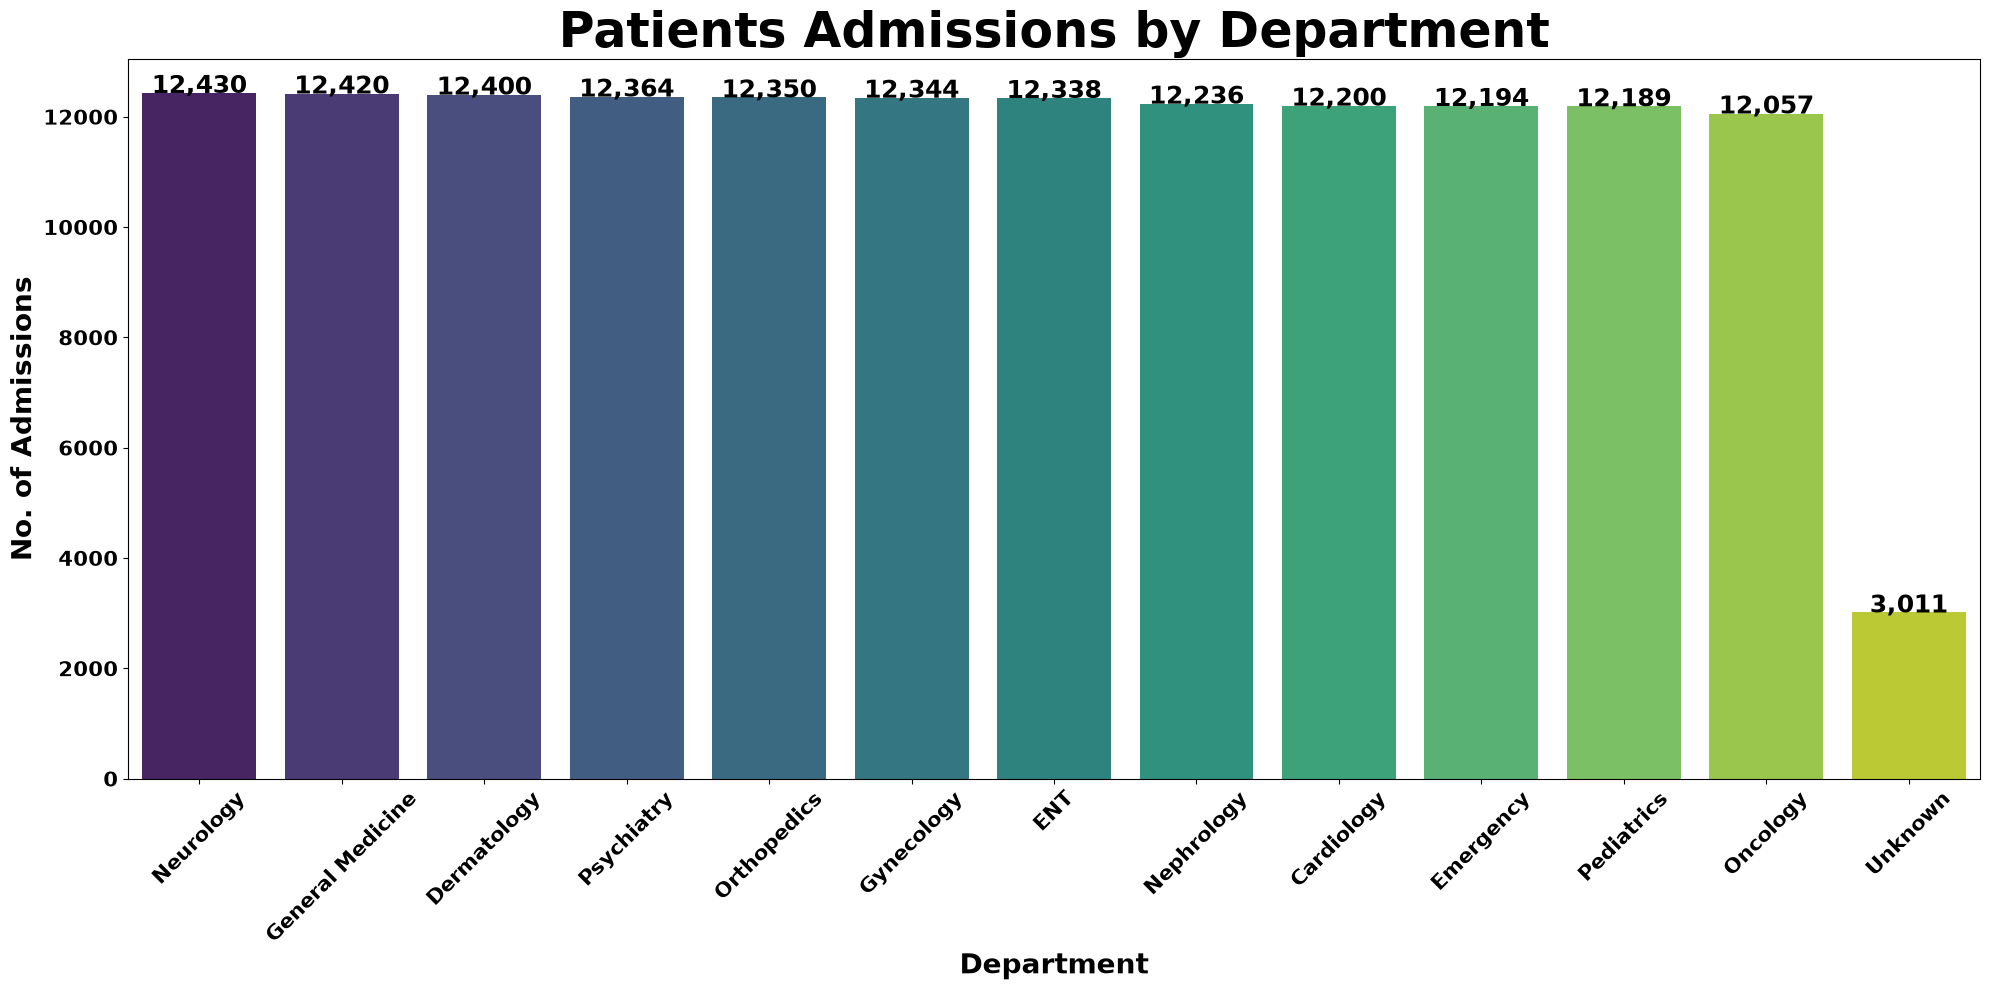

In [41]:
Admission_by_Department = hc.groupby('Department')['AdmissionDate'].count().sort_values(ascending=False)
plt.figure(figsize=(20,10))
sns.barplot(x = Admission_by_Department.index, y = Admission_by_Department.values, palette = 'viridis')
for x,y in zip(Admission_by_Department.index,Admission_by_Department.values):
    plt.text(x,y+0,f'{int(y):,}',ha = 'center',fontsize=18, fontweight = 'bold')
plt.title("Patients Admissions by Department", fontsize=35, fontweight = 'bold')
plt.xlabel('Department', fontsize=20, fontweight = 'bold')
plt.ylabel('No. of Admissions', fontsize=20, fontweight = 'bold')
plt.xticks(fontweight = 'bold', fontsize = 15, rotation = 45, ha = 'center')
plt.yticks(fontweight = 'bold', fontsize = 15)
plt.tight_layout()
plt.show

## Monthly admission trend (line chart)


<function matplotlib.pyplot.show(close=None, block=None)>

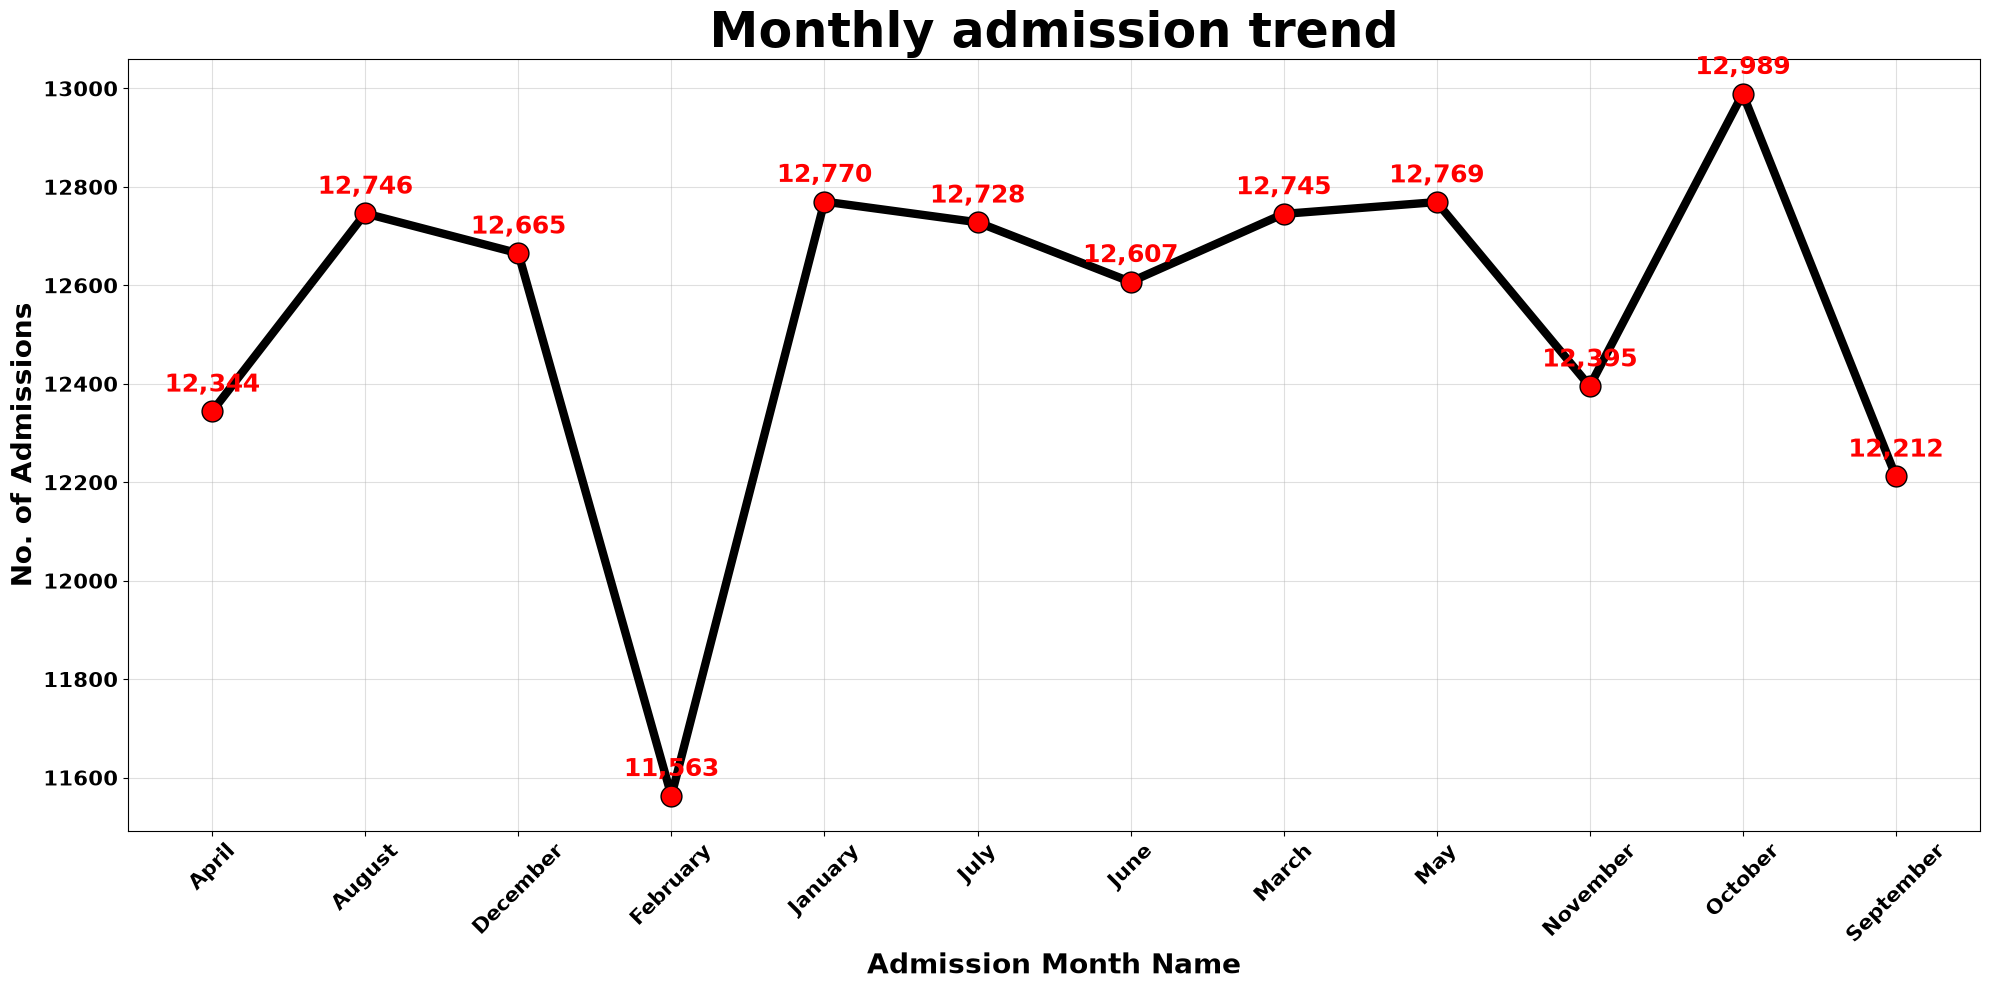

In [42]:
Monthly_admission_trend= hc.groupby('AdmissionMonthName')['AdmissionDate'].count()
plt.figure(figsize=(20, 10))
plt.plot(Monthly_admission_trend.index, Monthly_admission_trend.values, linewidth= 6, marker= 'o', color ='k', 
markerfacecolor='r', markersize = 15)
plt.grid(True, alpha=0.4)

for x,y in zip (Monthly_admission_trend.index,Monthly_admission_trend.values):
    plt.text(x,y+40,f'{int(y):,}',ha = 'center',fontsize=18, fontweight = 'bold', color = 'r')
plt.title("Monthly admission trend", fontsize=35, fontweight = 'bold')
plt.xlabel('Admission Month Name', fontsize=20, fontweight = 'bold')
plt.ylabel('No. of Admissions', fontsize=20, fontweight = 'bold')
plt.xticks(fontweight = 'bold', fontsize = 15, rotation = 45, ha = 'center')
plt.yticks(fontweight = 'bold', fontsize = 15)
plt.tight_layout()
plt.show

### **Billing amount by department (boxplot)**


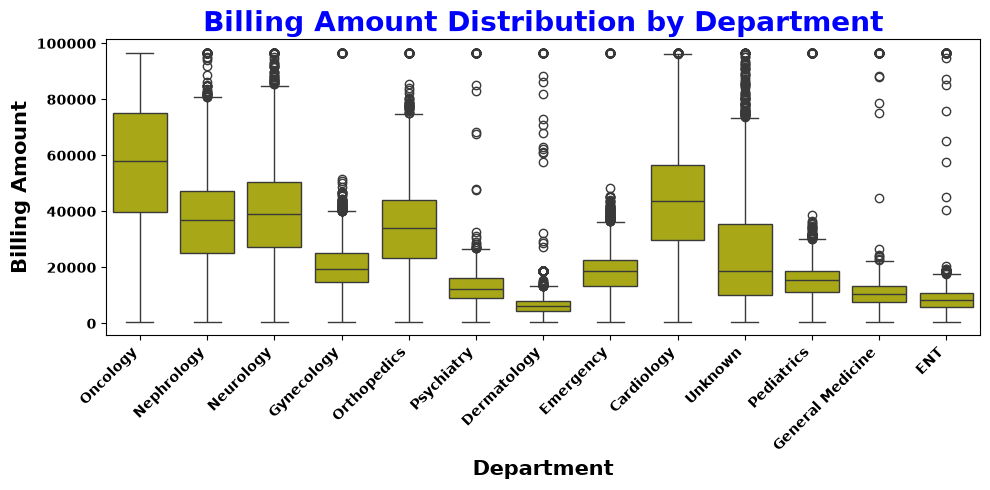

In [43]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Department', y='BillingAmount', data=hc, color ='y')
plt.title('Billing Amount Distribution by Department', fontsize=20, fontweight = 'bold', color ='b')
plt.xlabel('Department', fontsize=15, fontweight = 'bold',)
plt.ylabel('Billing Amount', fontsize=15, fontweight = 'bold')
plt.xticks(rotation=45, ha='right', fontsize=10, fontweight = 'bold')
plt.yticks(fontsize=10, fontweight = 'bold')

plt.tight_layout()

plt.show()


## Correlation heatmap

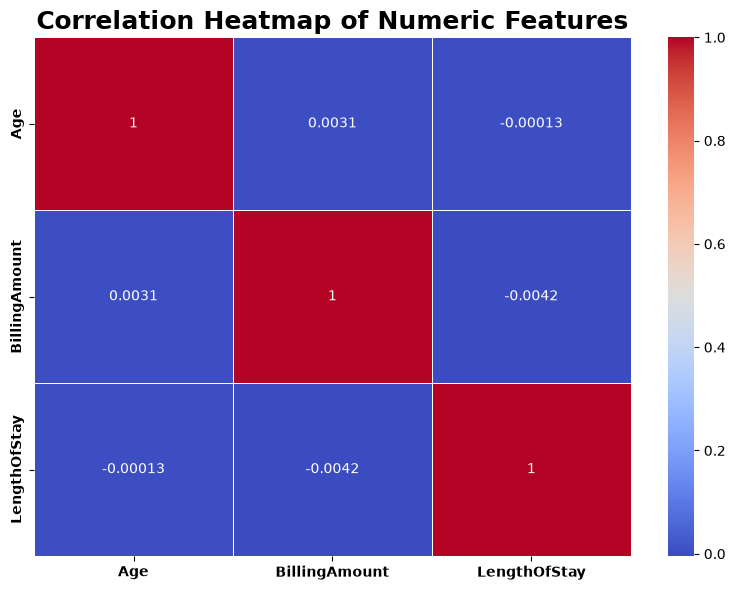

In [45]:
# List the numeric columns we want to check correlation between
numeric_cols = ["Age", "BillingAmount", "LengthOfStay"]

# Compute the correlation matrix for those numeric columns
corr = hc[numeric_cols].corr()

# Set the figure size for the heatmap
plt.figure(figsize=(8, 6))

# Draw the heatmap with correlation values annotated on each cell
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)

# Set the chart title
plt.title("Correlation Heatmap of Numeric Features", fontsize=18, fontweight = 'bold',color='k')
plt.xticks(fontsize=10, fontweight = 'bold')
plt.yticks(fontsize=10, fontweight = 'bold')

# Adjust spacing so labels aren't cut off
plt.tight_layout()

# Render the figure
plt.show()

## Insurance Provider Share (pie chart)

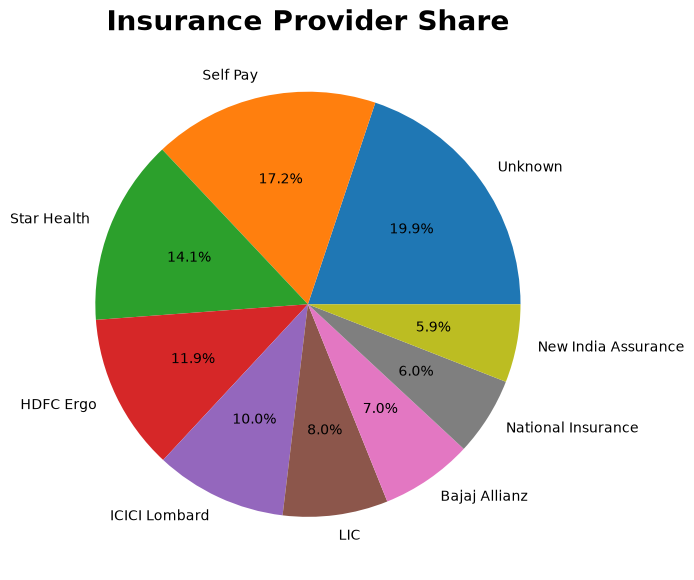

In [46]:
plt.figure(figsize=(7,7))
hc['InsuranceProvider'].value_counts().plot(kind='pie', autopct='%1.1f%%',)
plt.title('Insurance Provider Share', fontsize = 20, fontweight = 'bold')
plt.ylabel('', fontweight = 'bold')
plt.tight_layout()
plt.show()

In [49]:
## Save the cleaned dataset
hc.to_csv("healthcare_clean.csv", index=False)